In [ ]:
import pandas as pd
import numpy as np
import wrds
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt



path = "Data/predictions_ff3_vs_nn_2024_standard_retrain.parquet"
df = pd.read_parquet(path)

print(df.shape)
display(df.head())
print(df.dtypes)
print("Unique firms (permno):", df["permno"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())

(684286, 5)


,date,permno,excess_ret,ff3_pred,nn_pred
0,2024-01-02,10026,0.010091,-0.004505,-0.005502
1,2024-01-03,10026,-0.031824,-0.016249,-0.015596
2,2024-01-04,10026,-0.001423,-0.000603,-0.000413
3,2024-01-05,10026,-0.019242,-0.000454,-0.000186
4,2024-01-08,10026,0.005917,0.010641,0.012075


date          datetime64[ns]
permno                 Int64
excess_ret           Float64
ff3_pred             float64
nn_pred              float32
dtype: object
Unique firms (permno): 2716
Date range: 2024-01-02 00:00:00 to 2024-12-31 00:00:00


In [ ]:
# Squared errors at the firm-day level
df["se_ff3"] = (df["excess_ret"] - df["ff3_pred"])**2
df["se_nn"]  = (df["excess_ret"] - df["nn_pred"])**2

# Firm-level MSPEs over the 2024 test window
firm = (
    df.groupby("permno")
      .agg(
          n_obs=("date", "count"),
          mspe_ff3=("se_ff3", "mean"),
          mspe_nn=("se_nn", "mean"),
      )
)

firm["delta_mspe"] = firm["mspe_nn"] - firm["mspe_ff3"]     # <0 -> NN better
firm["improve"] = firm["mspe_nn"] < firm["mspe_ff3"]

# Share improved (equal-weighted across firms)
share_improve = firm["improve"].mean()
n_firms = len(firm)

print(f"Firms: {n_firms}")
print(f"Share improved (NN MSPE < FF3 MSPE): {share_improve:.4f} = {share_improve*100:.2f}%")


Firms: 2716
Share improved (NN MSPE < FF3 MSPE): 0.3325 = 33.25%


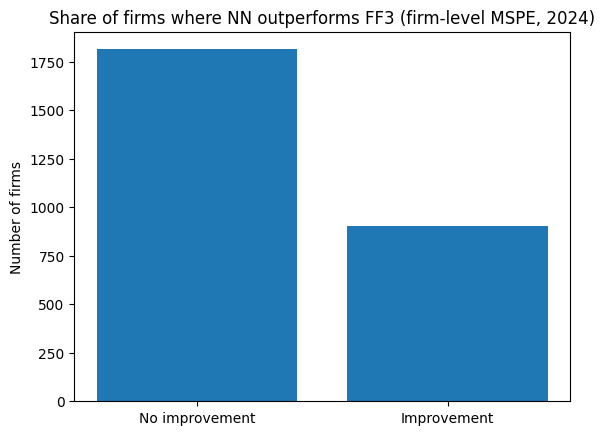

Counts:
improve
No improvement    1813
Improvement        903
Name: count, dtype: Int64


In [ ]:
counts = firm["improve"].value_counts().sort_index()  
labels = ["No improvement", "Improvement"]

plt.figure()
plt.bar(labels, [counts.get(False, 0), counts.get(True, 0)])
plt.title("Share of firms where NN outperforms FF3 (firm-level MSPE, 2024)")
plt.ylabel("Number of firms")
plt.show()

print("Counts:")
print(counts.rename(index={False: "No improvement", True: "Improvement"}))

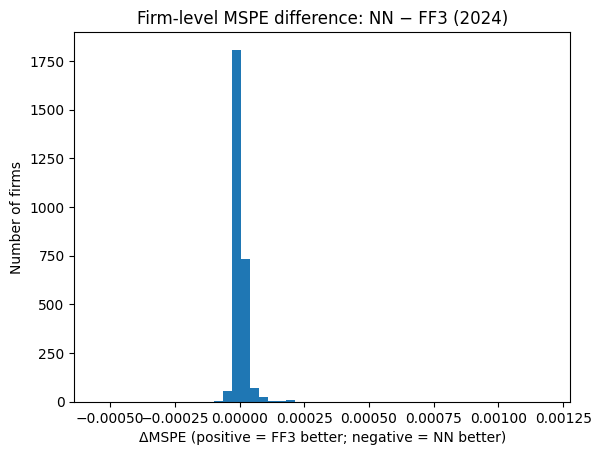

ΔMSPE summary:


count      2716.0
mean     0.000007
std      0.000037
min     -0.000551
10%     -0.000007
25%     -0.000002
50%      0.000003
75%      0.000009
90%      0.000022
max      0.001191
Name: delta_mspe, dtype: Float64

In [4]:
plt.figure()
plt.hist(firm["delta_mspe"].values, bins=50)
plt.title("Firm-level MSPE difference: NN − FF3 (2024)")
plt.xlabel("ΔMSPE (positive = FF3 better; negative = NN better)")
plt.ylabel("Number of firms")
plt.show()

print("ΔMSPE summary:")
display(firm["delta_mspe"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

In [5]:
# Compute firm-level mean return in OOS window
firm_mean_oos = (
    df.groupby("permno")["excess_ret"]
      .mean()
      .rename("mean_oos")
)

df = df.merge(firm_mean_oos, on="permno")

# Total Sum of Squares (OOS)
df["tss"] = (df["excess_ret"] - df["mean_oos"])**2

firm_r2 = (
    df.groupby("permno")
      .agg(
          sse_ff3=("se_ff3", "sum"),
          sse_nn=("se_nn", "sum"),
          tss=("tss", "sum")
      )
)

firm_r2["r2_ff3"] = 1 - firm_r2["sse_ff3"] / firm_r2["tss"]
firm_r2["r2_nn"]  = 1 - firm_r2["sse_nn"]  / firm_r2["tss"]

firm_r2["delta_r2"] = firm_r2["r2_nn"] - firm_r2["r2_ff3"]

firm_r2.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,sse_ff3,sse_nn,tss,r2_ff3,r2_nn,delta_r2
count,2716.0,2716.0,2716.0,2716.0,2716.0,2716.0
mean,0.483779,0.485485,0.516371,0.177185,0.171188,-0.005997
std,1.94303,1.944265,1.935065,0.203964,0.203942,0.016234
min,0.011477,0.011507,0.016302,-1.441865,-1.508526,-0.30971
10%,0.036698,0.037441,0.054744,-0.018997,-0.025118,-0.021533
25%,0.05993,0.060623,0.091294,0.029986,0.024582,-0.011919
50%,0.130187,0.132277,0.166669,0.141445,0.137289,-0.003972
75%,0.348562,0.350748,0.388141,0.292134,0.288618,0.002187
90%,0.908512,0.917577,0.976674,0.464462,0.457962,0.008396
max,54.959953,54.985357,54.782957,0.785683,0.772411,0.064933


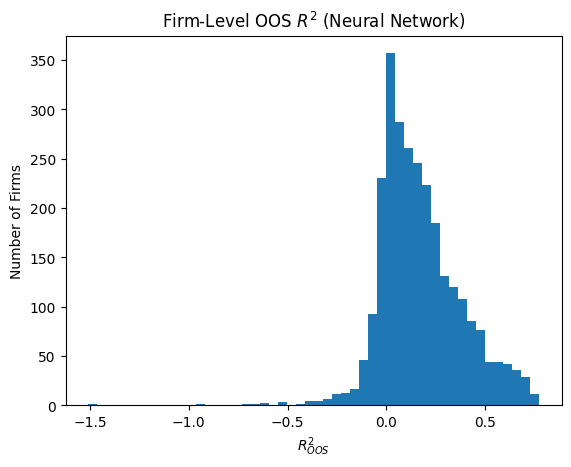

In [6]:
plt.figure()
plt.hist(firm_r2["r2_nn"], bins=50)
plt.title("Firm-Level OOS $R^2$ (Neural Network)")
plt.xlabel("$R^2_{OOS}$")
plt.ylabel("Number of Firms")
plt.show()

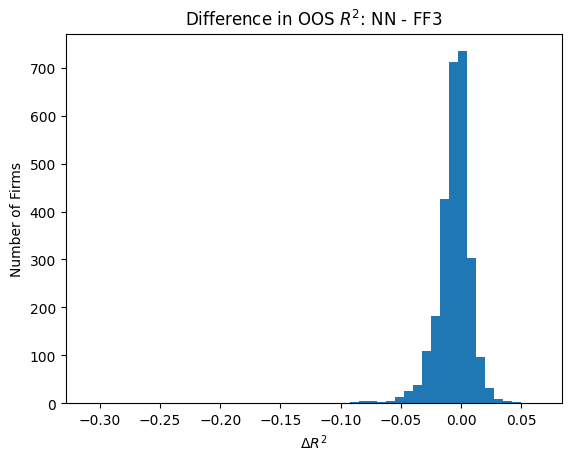

count      2716.0
mean    -0.005997
std      0.016234
min      -0.30971
10%     -0.021533
25%     -0.011919
50%     -0.003972
75%      0.002187
90%      0.008396
max      0.064933
Name: delta_r2, dtype: Float64

In [7]:
plt.figure()
plt.hist(firm_r2["delta_r2"], bins=50)
plt.title("Difference in OOS $R^2$: NN - FF3")
plt.xlabel("$\Delta R^2$")
plt.ylabel("Number of Firms")
plt.show()

firm_r2["delta_r2"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

In [8]:
db = wrds.Connection()

permnos_list = firm_r2.index.tolist()
permnos_sql = "(" + ",".join(map(str, permnos_list)) + ")"


# FF12 industry classification from SIC
def sic_to_ff12(sic):
    if sic != sic:  # NaN
        return "Other"
    sic = int(sic)

    if (100 <= sic <= 999) or (2000 <= sic <= 2399) or (2700 <= sic <= 2749) or (2770 <= sic <= 2799) or (3100 <= sic <= 3199) or (3940 <= sic <= 3989):
        return "Cnsmr"
    if (2500 <= sic <= 2599) or (3630 <= sic <= 3659) or (3710 <= sic <= 3711) or (3714 <= sic <= 3714) or (3716 <= sic <= 3716) or (3750 <= sic <= 3751) or (3792 <= sic <= 3792) or (3900 <= sic <= 3939) or (3990 <= sic <= 3999):
        return "Durbl"
    if (2520 <= sic <= 2589) or (2600 <= sic <= 2699) or (2750 <= sic <= 2769) or (3000 <= sic <= 3099) or (3200 <= sic <= 3569) or (3580 <= sic <= 3629) or (3700 <= sic <= 3709) or (3712 <= sic <= 3713) or (3715 <= sic <= 3715) or (3717 <= sic <= 3749) or (3752 <= sic <= 3791) or (3793 <= sic <= 3799) or (3830 <= sic <= 3839) or (3860 <= sic <= 3899):
        return "Manuf"
    if (1200 <= sic <= 1399) or (2900 <= sic <= 2999):
        return "Enrgy"
    if (2800 <= sic <= 2829) or (2840 <= sic <= 2899):
        return "Chems"
    if (3570 <= sic <= 3579) or (3660 <= sic <= 3692) or (3694 <= sic <= 3699) or (3810 <= sic <= 3829) or (7370 <= sic <= 7379):
        return "BusEq"
    if 4800 <= sic <= 4899:
        return "Telcm"
    if 4900 <= sic <= 4949:
        return "Utils"
    if 5000 <= sic <= 5999:
        return "Shops"
    if (2830 <= sic <= 2839) or (8000 <= sic <= 8099):
        return "Hlth"
    if 6000 <= sic <= 6999:
        return "Money"
    return "Other"


# Size: Market cap on last trading day of Dec 2023
query_me = f"""
select permno, date, abs(prc)*shrout as market_cap
from crsp.dsf
where permno in {permnos_sql}
  and date between '2023-12-01' and '2023-12-31'
"""
me = db.raw_sql(query_me)

# keep only positive market cap, then last obs in Dec
me = me[me["market_cap"] > 0].copy()
me = me.sort_values("date").groupby("permno").tail(1).copy()
me["log_mktcap"] = np.log(me["market_cap"])


# Sector: SIC from stocknames as of 2023-12-31
query_sic = f"""
select permno, siccd as sic
from crsp.stocknames
where permno in {permnos_sql}
  and namedt <= '2023-12-31'
  and (nameenddt is null or nameenddt >= '2023-12-31')
"""
sic = db.raw_sql(query_sic).drop_duplicates("permno")
sic["sector_ff12"] = sic["sic"].apply(sic_to_ff12)

# combine size + sector
chars = me.merge(sic[["permno", "sector_ff12"]], on="permno", how="left")


# Volatility: fetch daily returns from CRSP for 2023 and compute std
# This is return volatility, not excess return volatility
query_ret = f"""
select permno, date, ret
from crsp.dsf
where permno in {permnos_sql}
  and date between '2023-01-01' and '2023-12-31'
"""
rets = db.raw_sql(query_ret)

# CRSP ret can be null/non-numeric; clean then compute firm-level std
rets = rets.dropna(subset=["ret"]).copy()
rets["ret"] = rets["ret"].astype(float)

vol_2023 = (
    rets.groupby("permno")["ret"]
        .std()
        .rename("volatility_2023")
        .reset_index()
)

# Build regression dataset
firm_reg = (
    firm_r2.reset_index()
          .merge(chars[["permno", "log_mktcap", "sector_ff12"]], on="permno", how="inner")
          .merge(vol_2023, on="permno", how="inner")
)

print("N:", firm_reg.shape[0])
print("Sector counts:\n", firm_reg["sector_ff12"].value_counts(dropna=False))

# Cross-sectional regression
model = smf.ols(
    "delta_r2 ~ log_mktcap + volatility_2023 + C(sector_ff12)",
    data=firm_reg
).fit(cov_type="HC3")

print(model.summary())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
N: 2716
Sector counts:
 sector_ff12
Other    982
Money    431
BusEq    299
Manuf    216
Shops    209
Hlth     146
Cnsmr    115
Enrgy     82
Utils     67
Durbl     60
Chems     57
Telcm     52
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:               delta_r2   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     2.793
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           0.000564
Time:                        13:04:06   Log-Likelihood:                 7501.7
No. Observations:                2716   AIC:                        -1.498e+04
Df Residuals:                    270

In [ ]:
#Needed for XAI bit
firm_perf = firm_r2.reset_index()[["permno", "delta_r2"]]
firm_perf.to_parquet("Data/firm_level_performance_2024.parquet", index=False)

In [ ]:
#Needed for XAI bit
firm_sector = firm_reg[["permno", "sector_ff12"]].drop_duplicates()
firm_sector.to_parquet("Data/firm_level_sector_2024.parquet", index=False)